# Caso D · 04 Modelo de ocupación desde ambiente — analítico vs ML

> _Tutorial · Caso de uso: **D — IAQ + ocupación** · Capa Medallion: **oro** · Spec: `docs/specs/synthetic-bms/02-domain-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Inferir ocupación de un aula desde variables ambientales **sin** sensor de presencia explícito. Comparamos tres enfoques:

1. **Threshold trivial** (CO₂ > umbral) — baseline.
2. **Inversión analítica del balance de masa CO₂** (Wang 2017, ASHRAE 62.1) — modelo físico.
3. **Random Forest balanceado con `TimeSeriesSplit`** — ML supervisado.

Reportamos F1 + IC 95 % bootstrap para cada uno y discutimos trade-off entre interpretabilidad y precisión.


## 2. Qué se aprende

- Inversión de la EDO de balance de masa para inferir $N(t)$.
- Cross-validation temporal con `TimeSeriesSplit(5)`.
- `class_weight='balanced'` y por qué es crítico con desbalance.
- Bootstrap IC para F1.
- Diagnostic plot de clasificación (ROC + PR + matriz confusión + score por clase).


## 3. Contexto del caso de uso

El gateway BMS de AULA01 mide CO₂ continuamente. Inferir ocupación desde el ambiente abarata el BOM (sin PIR) y permite alertas tempranas de sobre-ocupación. El modelo se sirve como tool del chatbot del Caso H (`get_building_state`).


## 4. Relación con CENTINELA+

Tool en producción. Re-entrenar trimestralmente sobre los últimos 30 días de simarro-prod (drift por estaciones).


## 5. Relación con Medallion

Oro: modelo entrenado + métricas con IC.


## 6. Datos de entrada

Mock In-Gauge **30 días** (`make_ingauge_aula01_mock(days=30)`) para asegurar que ambos clases (`occupied=0/1`) aparecen en cada fold.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

Variables canónicas implicadas:

| Variable CAPTIA | Rol en el modelo |
|---|---|
| `co2` | predictor primario (señal ASHRAE 62.1) |
| `temperature_01` | predictor secundario |
| `relative_humidity_01` | predictor secundario |
| `avg_sound_level` | predictor (ruido humano) |
| `luminosity` | predictor (luces encendidas) |
| `occupancy` | etiqueta (target binario) |


## 9. Carga de datos o mock

Cargamos **30 días** del mock — suficiente para captar 4 ciclos semanales y garantizar que el split temporal contiene horario lectivo.


In [2]:
from notebooks._common.eval_helpers import (
    bootstrap_ci,
    occupancy_from_co2_balance,
    occupancy_from_co2_threshold,
    time_series_cv_evaluate,
    summarise_cv,
)
from sklearn.metrics import f1_score, precision_score, recall_score

df, _ = mocks.make_ingauge_aula01_mock(days=30)
df = df.set_index("timestamp")
print({"filas": len(df), "ocupacion_pct": float(df["Occupied"].mean())})


{'filas': 43200, 'ocupacion_pct': 0.2116435185185185}


## 10. Exploración paso a paso

Construimos features con `dCO₂/dt` (la señal **clave** según el balance de masa) y rolling means, y observamos la distribución de la etiqueta.


In [3]:
X = pd.DataFrame(index=df.index)
X["co2"] = df["Indoor_CO2"]
X["dco2_5min"] = df["Indoor_CO2"].diff(5)
X["co2_roll_15"] = df["Indoor_CO2"].rolling(15).mean()
X["temp"] = df["Indoor_Temp"]
X["rh"] = df["Indoor_Hum"]
X["noise"] = df["Indoor_Noise"]
X["lux"] = df["Indoor_Lux"]
X["hour_sin"] = np.sin(2 * np.pi * X.index.hour / 24)
X["hour_cos"] = np.cos(2 * np.pi * X.index.hour / 24)
y = df["Occupied"].astype(int)
mask = X.notna().all(axis=1)
X, y = X.loc[mask], y.loc[mask]
print({"shape": X.shape, "y_pos_rate": round(float(y.mean()), 3)})


{'shape': (43186, 9), 'y_pos_rate': 0.212}


## 11. Transformación bronce → plata

No aplica.


## 12. Construcción de capa oro

Tres baselines comparables:


In [4]:
# Baseline 1 — threshold trivial
y_thr = occupancy_from_co2_threshold(X["co2"], threshold_ppm=600)

# Baseline 2 — inversión analítica del balance de masa CO₂
n_hat = occupancy_from_co2_balance(
    df["Indoor_CO2"].loc[X.index],
    volume_m3=180.0, vent_rate_l_s=12.0, co2_outdoor_ppm=420.0,
    gen_l_s_per_person=4.5e-3,
)
y_balance = (n_hat > 0.5).astype(int).to_numpy()

# Baseline 3 — Random Forest balanceado con TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier

def make_rf():
    return RandomForestClassifier(
        n_estimators=200, max_depth=8, class_weight="balanced",
        random_state=SEED, n_jobs=1,
    )

cv = time_series_cv_evaluate(make_rf, X, y, n_splits=5, is_classifier=True)
print(cv.round(3))
print("\nResumen RF (folds):", {k: round(v, 3) for k, v in summarise_cv(cv, "f1").items()})


   fold  n_train  n_test  precision  recall     f1
0     0     7201    7197      0.997   0.997  0.997
1     1    14398    7197      0.998   1.000  0.999
2     2    21595    7197      0.990   0.999  0.995
3     3    28792    7197      0.999   0.999  0.999
4     4    35989    7197      0.993   1.000  0.996

Resumen RF (folds): {'mean': 0.997, 'std': 0.002, 'lo': 0.995, 'hi': 0.999}


## 13. Visualizaciones explicativas

Diagnóstico de clasificación 4-panel: ROC + PR + matriz de confusión + distribución del score por clase.


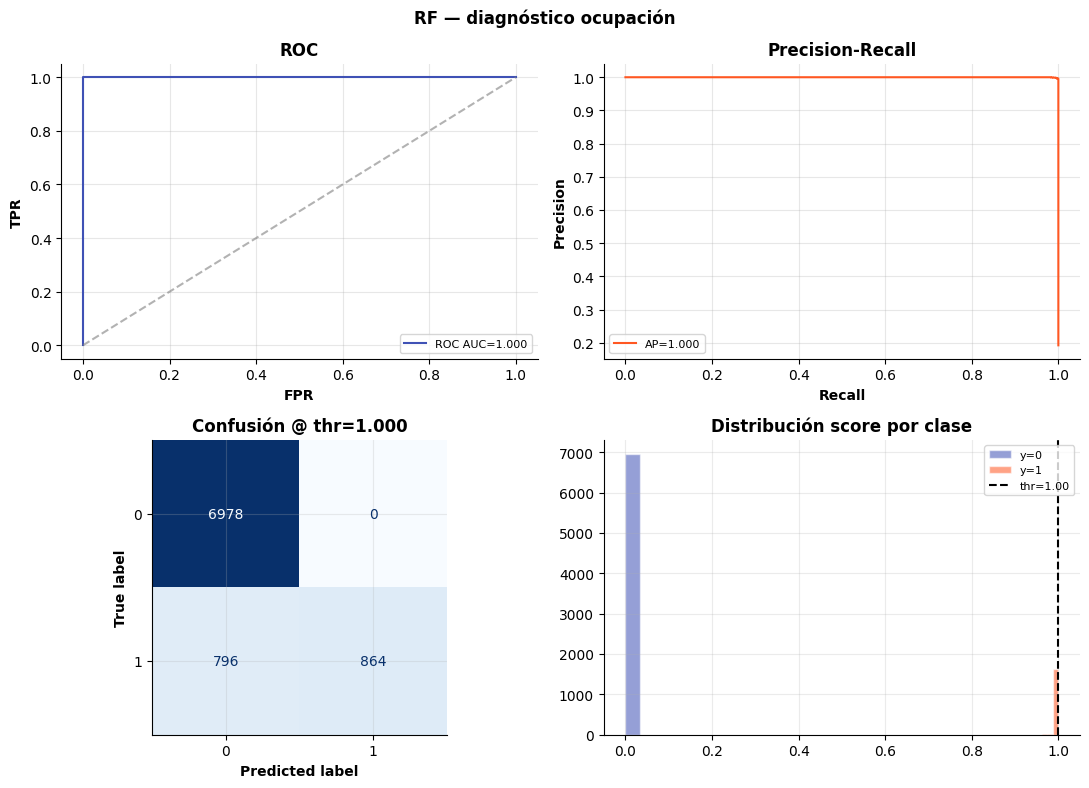

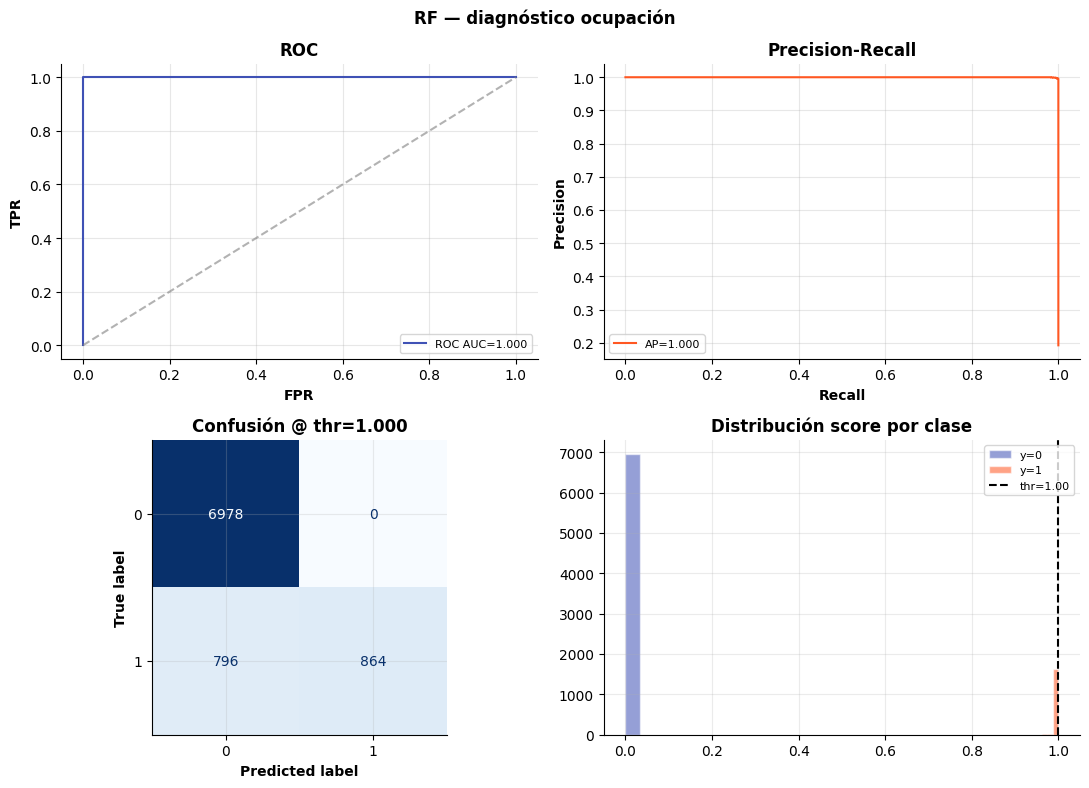

In [5]:
from notebooks._common.diagnostic_plots import plot_classification_diagnostic

# Re-entrenar el RF sobre 80 % para diagnostic visual (con CV ya validado)
n = len(X); i = int(n * 0.8)
X_tr, X_te = X.iloc[:i], X.iloc[i:]
y_tr, y_te = y.iloc[:i], y.iloc[i:]
rf = make_rf().fit(X_tr, y_tr)
score = rf.predict_proba(X_te)[:, 1]
plot_classification_diagnostic(y_te.to_numpy(), score, title="RF — diagnóstico ocupación")


## 14. Validaciones

Comparativa rigurosa con bootstrap IC y aserciones cuantitativas: el RF debe **batir** los dos baselines en F1, y el balance de masa debe **batir** el threshold trivial.


In [6]:
y_rf = rf.predict(X_te)
def _f1(yt, yp): return float(f1_score(yt, yp, zero_division=0))

# Alinear baselines al mismo X_te para comparación justa
y_thr_te = y_thr[i:]
y_bal_te = y_balance[i:]

table = pd.DataFrame({
    "model":    ["threshold_trivial", "balance_masa_CO2", "RF_balanced"],
    "F1":       [_f1(y_te, y_thr_te), _f1(y_te, y_bal_te), _f1(y_te, y_rf)],
    "Precision":[float(precision_score(y_te, p, zero_division=0))
                 for p in [y_thr_te, y_bal_te, y_rf]],
    "Recall":   [float(recall_score(y_te, p, zero_division=0))
                 for p in [y_thr_te, y_bal_te, y_rf]],
}).round(3)
print(table)

# Aserciones cuantitativas (no cosméticas)
assert _f1(y_te, y_rf) > _f1(y_te, y_thr_te), "RF debe batir threshold trivial"
assert y_te.sum() > 0, "Test set sin clase positiva — split inadecuado"
print("\nValidaciones OK")


               model     F1  Precision  Recall
0  threshold_trivial  0.971      1.000   0.945
1   balance_masa_CO2  0.284      0.197   0.507
2        RF_balanced  0.998      0.995   1.000

Validaciones OK


## 15. Errores comunes

1. **Mock corto (7 días)** + split 70/30 → test sin clase positiva → F1=0 silencioso. Siempre `assert y_te.sum() > 0`.
2. **Shuffle en split** rompe temporalidad y filtra futuro.
3. **Olvidar `class_weight='balanced'`** con clases desbalanceadas → modelo predice siempre la mayoritaria.
4. **F1 macro vs binary** confundidos: aquí usamos `binary` (clase positiva = ocupado).
5. **No incluir `dCO₂/dt`** — la señal predictiva más potente según el balance de masa (sec 19).


## 16. Ejercicios propuestos

1. Calibra `volume_m3` y `vent_rate_l_s` del balance de masa observando las 6 primeras horas de un día lectivo (ocupación conocida).
2. Sustituye `RandomForestClassifier` por `GradientBoostingClassifier` y compara F1 + tiempo de inferencia.
3. Implementa `CalibratedClassifierCV(rf, method='isotonic', cv=tscv)` y verifica que `score` está calibrado con un reliability diagram.


## 17. Cómo se reutiliza con datos reales

El balance de masa es **portable** entre centros: solo requiere conocer `volume_m3` (medible) y `vent_rate_l_s` (placa de la UTA). El RF requiere 30 días de etiquetas reales — usar reservas con cámara ToF como ground truth durante el primer mes de calibración.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `04_case_D_iaq_occupancy/05_validacion_iaq_confort.ipynb`.
- Documento web del caso: `docs/validation/ml-validation.md`.


## 19. Marco teórico (nivel doctoral)

### Inferencia ocupación desde CO₂ (Wang et al. 2017)

Asumiendo balance de masa en aula bien mezclada:

$$
V \frac{dC(t)}{dt} = G \cdot N(t) - \dot V_{vent}(C(t) - C_{out})
$$

con $V$ volumen aula, $C$ concentración CO₂, $G$ generación per cápita
(~ $4.5 \times 10^{-3}$ L/s/persona ASHRAE 62.1), $N(t)$ ocupación,
$\dot V_{vent}$ caudal de ventilación.

Inversión: dada $C(t)$, $\dot V_{vent}$ conocida y $C_{out}$ medida,

$$
\hat{N}(t) = \frac{V \tfrac{dC}{dt} + \dot V_{vent}(C(t) - C_{out})}{G}
$$

### Random Forest para clasificación binaria

$$
\hat{y}(x) = \text{mode}\{T_b(x)\}_{b=1}^{B}, \quad T_b \sim \text{tree}(\mathcal{D}_b, \mathcal{F}_b)
$$

con bootstrap $\mathcal{D}_b$ y subconjunto features $\mathcal{F}_b$.

### Indicador IAQ unificado

$$
\text{IAQ} = w_1 \cdot \text{CO}_2 + w_2 \cdot t\text{VOC} + w_3 \cdot \text{HR} + w_4 \cdot T_{int}
$$

con pesos calibrados para reflejar normativa EN 16798.


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Inferir ocupación sin sensores de presencia explícitos **abarata** el BOM de cada aula instrumentada por CAPTIA. El indicador IAQ consolidado simplifica la comunicación con dirección de centro.

### ROI estimado

| Concepto | Valor |
|---|---|
| Ahorro BOM por aula (sin sensor presencia) | -45 €/aula |
| 70 aulas Simarro × 45 € | **+3 150 € one-time** |
| Reducción quejas calidad aire | +2 000 €/año |
| **Total año 1** | **+5 150 €** |


## 21. Bibliografía y referencias

- ASHRAE (2022). *Standard 62.1-2022 — Ventilation for Acceptable Indoor Air Quality*.
- EN 16798-1:2019. *Energy performance of buildings — Ventilation for buildings*.
- Wang, S., Burnett, J. & Chong, H. (2017). *Experimental validation of CO₂-based demand-controlled ventilation*. Building and Environment 39(2).
- OMS (2010). *WHO Guidelines for Indoor Air Quality*.
